# Workshop 2: Convergence Analysis of IVP problems

In this workshop, we will:

1. verify the fifth-order convergence numerically for the RK5 scheme.
2. Convergence analysis for the forward Euler scheme. 
2. introduce adaptive timestepping through RK45.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Problem definition


We solve the following ODE - 

$$m\ddot{u} + c\dot{u} + ku = 0$$

With the state vector being -

$$
\boldsymbol{q} =
\begin{bmatrix}
u \\
\dot{u}
\end{bmatrix}$$

We start by defining the numerical parameters for this mass-spring-damper system.

In [2]:
# System parameters
m = 1.0      # mass [kg]
c = 0.2      # damping [Ns/m]
k = 4.0      # stiffness [N/m]

# Time interval
t_0 = 0.0
t_f = 10.0

# Initial conditions
init_disp = 1.0
init_velo = 0.0
q0 = [init_disp, init_velo]

# Define the system of equations
def q_dot(t, q):
    u = q[0]
    v = q[1]

    du_dt = v
    dv_dt = -(k/m) * u - (c/m) * v

    return np.array([du_dt, dv_dt])

## Exact solution

We define -

$$
\omega_n = \sqrt{\frac{k}{m}}, \qquad
\zeta = \frac{c}{2\sqrt{km}}.
$$

For the underdamped case $(\zeta < 1)$, the damped frequency is

$$
\omega_d = \omega_n\sqrt{1-\zeta^2}.
$$

The exact displacement is

$$
u(t)=e^{-\zeta\omega_n t}
\left[
u_0\cos(\omega_d t)
+
\frac{v_0+\zeta\omega_n u_0}{\omega_d}\sin(\omega_d t)
\right].
$$

This exact solution allows us to measure the numerical error directly.

### We define the exact solution

In [3]:
omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(k * m))

if zeta >= 1.0:
    raise ValueError("This notebook uses the underdamped exact solution, so choose parameters with zeta < 1.")

omega_d = omega_n * np.sqrt(1 - zeta**2)

def u_exact(t):
    A = q0[0]
    B = (q0[1] + zeta * omega_n * q0[0]) / omega_d
    t = np.asarray(t)
    return np.exp(-zeta * omega_n * t) * (
        A * np.cos(omega_d * t) + B * np.sin(omega_d * t)
    )

def v_exact(t):
    A = q0[0]
    B = (q0[1] + zeta * omega_n * q0[0]) / omega_d
    t = np.asarray(t)
    exp_term = np.exp(-zeta * omega_n * t)
    return exp_term * (
        -zeta * omega_n * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
        -A * omega_d * np.sin(omega_d * t)
        +B * omega_d * np.cos(omega_d * t)
    )

# Exact solution state function
def q_exact(t):
    return np.vstack((u_exact(t), v_exact(t)))

## Convergence analysis

For a fifth-order Runge–Kutta method, the global error is expected to behave like

$$
ϵ(Δt) \sim C Δt^5.
$$

To verify this numerically, we solve the same problem on a sequence of timestep grids and compute the error with respect to the exact solution.

We estimate the observed order of convergence by measuring the slope of the best-fit line in a log-log plot of $\epsilon$ versus $\Delta t$.

In [4]:
dt_values = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])
errors_final_time = []
errors_max = []

def solve_at_dt(dt):
    t_eval = np.arange(t_0, t_f + 0.5 * dt, dt)

    sol = solve_ivp(
        fun=q_dot,
        t_span=(t_0, t_f),
        y0=q0,
        t_eval=t_eval,
        max_step=dt # Ensure that the solver does not take steps larger than dt
    )
    return sol, t_eval

In [5]:
# Loop over different time step sizes and compute errors using the function solve_at_dt
for dt in dt_values:

    sol_i, t_eval = solve_at_dt(dt)

    q_exact_dt = q_exact(t_eval)

    # Error at the final time
    err_final = np.linalg.norm(sol_i.y[:, -1] - q_exact_dt[:, -1])

    # Maximum error over all time steps
    err_max = np.max(np.linalg.norm(sol_i.y - q_exact_dt, axis=0))

    errors_final_time.append(err_final)
    errors_max.append(err_max)

We now plot the errors we have obtained

In [6]:
# log-log fit
slope_final_timestep, _ = np.polyfit(np.log(dt_values), np.log(errors_final_time), 1)
slope_max, _   = np.polyfit(np.log(dt_values), np.log(errors_max), 1)

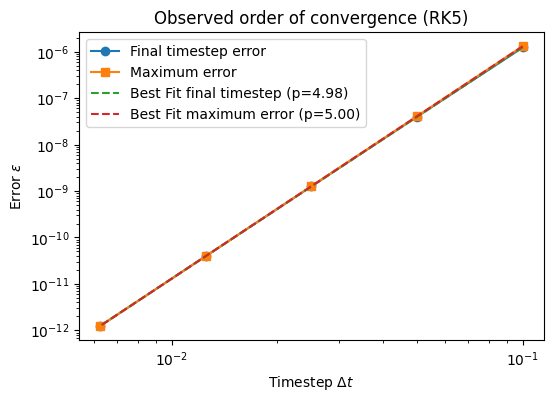

In [7]:
plt.figure(figsize=(6,4))

# data
plt.loglog(dt_values, errors_final_time, "o-", label="Final timestep error")
plt.loglog(dt_values, errors_max, "s-", label="Maximum error")

# fitted lines
plt.loglog(
    dt_values,
    np.exp(np.polyfit(np.log(dt_values), np.log(errors_final_time), 1)[1]) * dt_values**slope_final_timestep,
    "--",
    label=f"Best Fit final timestep (p={slope_final_timestep:.2f})"
)

plt.loglog(
    dt_values,
    np.exp(np.polyfit(np.log(dt_values), np.log(errors_max), 1)[1]) * dt_values**slope_max,
    "--",
    label=f"Best Fit maximum error (p={slope_max:.2f})"
)

plt.xlabel(r"Timestep $\Delta t$")
plt.ylabel(r"Error $\epsilon$")
plt.title("Observed order of convergence (RK5)")
plt.legend()
plt.show()

We now perform the convergence analysis for the Forward Euler method using the ```FE_solver``` implementation we observed in Workshop 1.

In [8]:
# FE solver
def FE_solver(qdot, tspan, q0):

    # Initialize the solution vector at the times we want to evaluate.
    # Match solve_ivp's state layout: one column per timestep, one row per state variable.
    nsteps = len(tspan)
    q = np.zeros((2, nsteps))

    # Fill initial step
    q[:, 0] = q0

    # Loop over time entries
    for i in range(nsteps - 1):
        # Evaluate the derivative using the function provided as argument
        dt_step = tspan[i + 1] - tspan[i]
        dq = qdot(tspan[i], q[:, i])
        # Update the solution vector at step "i"
        q[:, i + 1] = q[:, i] + np.multiply(dq, dt_step)

    return q



In [9]:
dt_values = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])
errors_final_time = []
errors_max = []

def solve_at_dt_FE_solver(dt):
    t_eval = np.arange(t_0, t_f + 0.5 * dt, dt)

    sol = FE_solver(
        qdot=q_dot,
        tspan=t_eval,
        q0=q0
    )
    return sol, t_eval

In [10]:
# Loop over different time step sizes and compute errors using the function solve_at_dt
for dt in dt_values:

    sol_i, t_eval = solve_at_dt_FE_solver(dt)

    q_exact_dt = q_exact(t_eval)

    # Error at the final time
    err_final = np.linalg.norm(sol_i[:, -1] - q_exact_dt[:, -1])

    # Maximum error over all time steps
    err_max = np.max(np.linalg.norm(sol_i - q_exact_dt, axis=0))

    errors_final_time.append(err_final)
    errors_max.append(err_max)

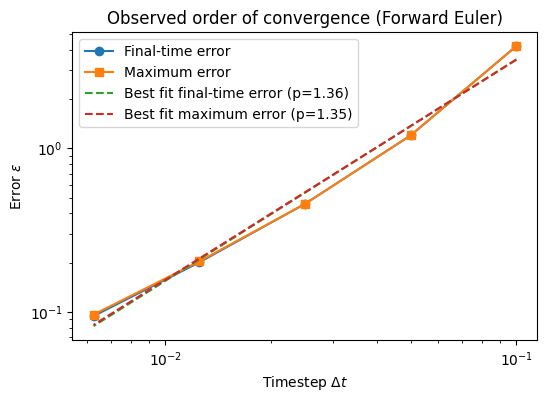

In [11]:
# log-log fit
slope_final_timestep, intercept_final = np.polyfit(np.log(dt_values), np.log(errors_final_time), 1)
slope_max, intercept_max = np.polyfit(np.log(dt_values), np.log(errors_max), 1)

plt.figure(figsize=(6,4))

# error data
plt.loglog(dt_values, errors_final_time, "o-", label="Final-time error")
plt.loglog(dt_values, errors_max, "s-", label="Maximum error")

# fitted lines
plt.loglog(
    dt_values,
    np.exp(intercept_final) * np.array(dt_values)**slope_final_timestep,
    "--",
    label=f"Best fit final-time error (p={slope_final_timestep:.2f})"
)

plt.loglog(
    dt_values,
    np.exp(intercept_max) * np.array(dt_values)**slope_max,
    "--",
    label=f"Best fit maximum error (p={slope_max:.2f})"
)

plt.xlabel(r"Timestep $\Delta t$")
plt.ylabel(r"Error $\epsilon$")
plt.title("Observed order of convergence (Forward Euler)")
plt.legend()
plt.show()

## Adaptive timestepping 

In the previous section, we enforced a restricted timestep using `max_step` to study convergence with respect to $\Delta t$. 

In practice, however, `solve_ivp` with `RK45` does not use a fixed timestep. Instead, it automatically adjusts the timestep based on an estimate of the local error. This is known as **adaptive timestepping**.

In [12]:
#  Function to solve the system using an adaptive time-stepping method (RK45)
def solve_adaptive(rtol=1e-6, atol=1e-9):
    sol = solve_ivp(
        fun=q_dot,
        t_span=(t_0, t_f),
        y0=q0,
        method="RK45",
        rtol=rtol,
        atol=atol
    )
    return sol

We now vary the relative tollarence in ```solve_adaptive``` to investigate the number of timesteps selected by the solver for different tollarence values selected. 

In [13]:
# Tolerance values to test
rtol_values = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

nsteps = []
errors_final_time = []
errors_max = []

for rtol in rtol_values:
    atol = rtol * 1e-3
    sol_i = solve_adaptive(rtol=rtol, atol=atol)

    # Exact solution evaluated at the adaptive time points
    q_ex = q_exact(sol_i.t)

    # Pointwise error in time
    error_time = np.linalg.norm(sol_i.y - q_ex, axis=0)

    # Number of accepted timesteps
    nsteps.append(len(sol_i.t) - 1)

    # Error measures
    errors_final_time.append(error_time[-1])
    errors_max.append(np.max(error_time))

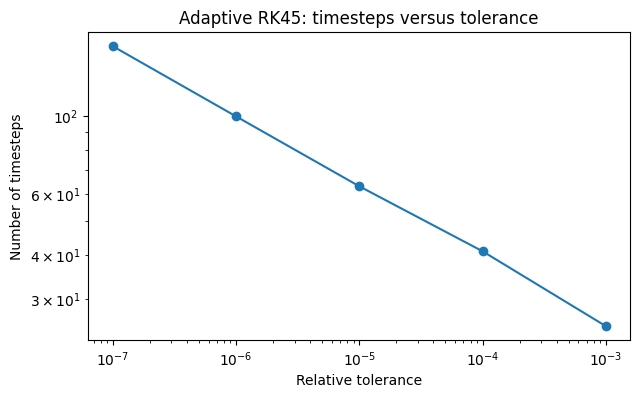

In [14]:
plt.figure(figsize=(7,4))
plt.loglog(rtol_values, nsteps, "o-")
plt.xlabel("Relative tolerance")
plt.ylabel("Number of timesteps")
plt.title("Adaptive RK45: timesteps versus tolerance")
plt.show()